In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [ ]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as stats
import statsmodels.api as sm

from data.data import get_multiple_stocks_data

# setup
plt.style.use("dark_background")
mpl.rcParams['font.family'] = 'serif'
significance_level = 0.05
tickers = ["SPY", "GLD", "NVDA", "GOOGL", "BTC-USD"]
data = get_multiple_stocks_data(tickers, "2016-06-01", "2026-06-01", "1d")

# computations
# simple comps: prices + log returns
prices = {tickers[i]: data[tickers[i]]["Close"].values for i in range(len(tickers))}
log_returns = {ticker: np.diff(np.log(prices[ticker])) for ticker in tickers} # under GBM assumptions, log returns ~ N(mu * dt, sigma^2 * dt)
log_returns_squared = {ticker: log_returns[ticker] ** 2 for ticker in tickers}

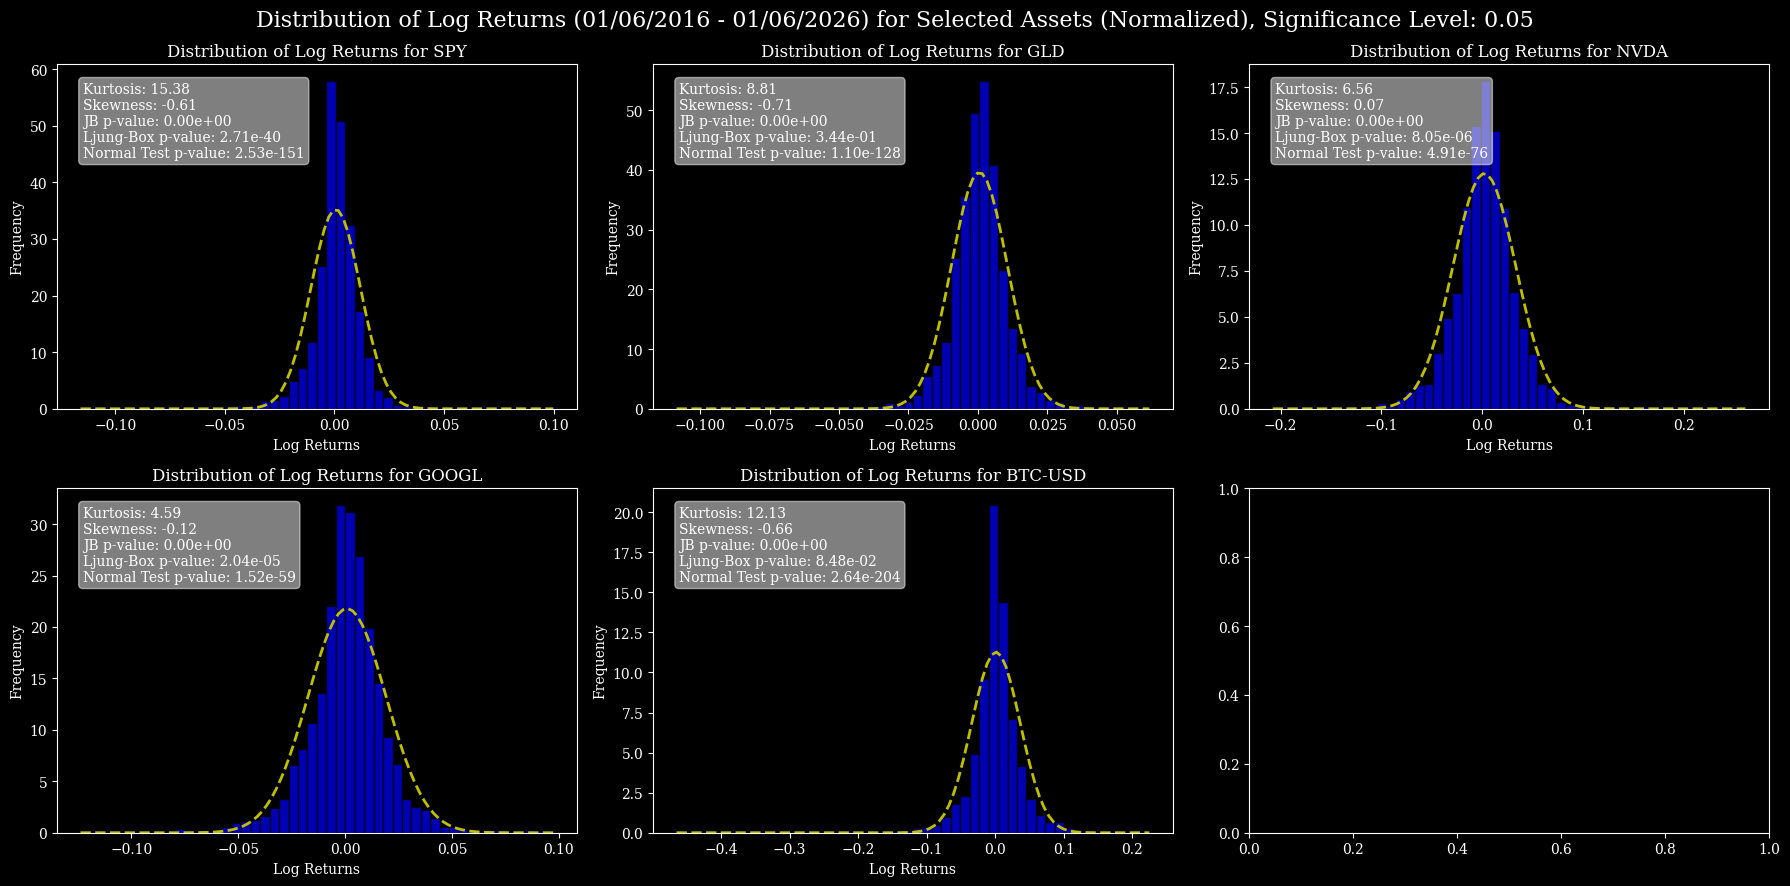

In [ ]:
# complex comps: kurtosis, skewness, normality tests e.g. JB test, Ljung-Box test, normal test
excess_kurtosis = {}
skewness = {}
jb_test_results = {}
ljung_box_test_results = {}
normal_tests_results = {}
  
# plotting, for every 3 tickers, change rows
fig, axs = plt.subplots(len(tickers) // 3 + (1 if len(tickers) % 3 else 0), 3, figsize=(18, 9), squeeze=False)
fig.suptitle(f"Distribution of Log Returns (01/06/2016 - 01/06/2026) for Selected Assets (Normalized), Significance Level: {significance_level}", fontsize=16)

for i, ticker in enumerate(tickers):
  excess_kurtosis[ticker] = stats.kurtosis(log_returns[ticker]) # also called Fisher's kurtosis, which is excess kurtosis (kurtosis - 3)
  skewness[ticker] = stats.skew(log_returns[ticker])
  jb_test_results[ticker] = stats.jarque_bera(log_returns[ticker]) # the Jarque-Bera test combines skewness and kurtosis to test for normality
  ljung_box_test_results[ticker] = sm.stats.diagnostic.acorr_ljungbox(log_returns[ticker], lags=[10], return_df=True)
  normal_tests_results[ticker] = stats.normaltest(log_returns[ticker])

  # plot the distribution of log returns, and overlay a normal distribution for comparison
  ax = axs[i // 3, i % 3]
  
  ax.hist(log_returns[ticker], bins=50, alpha=0.7, color='blue', density=True, edgecolor='black')
  ax.set_xlabel('Log Returns')
  ax.set_ylabel('Frequency')
  ax.set_title(f'Distribution of Log Returns for {ticker}')
  # Overlay a normal distribution
  normal_x_axis= np.linspace(log_returns[ticker].min(), log_returns[ticker].max(), 100)
  normal_pdf_line = stats.norm.pdf(normal_x_axis, log_returns[ticker].mean(), log_returns[ticker].std())
  ax.plot(normal_x_axis, normal_pdf_line, 'y--', linewidth=2)

  # print the stats in the title or as text on the plot
  stats_text = f"Kurtosis: {excess_kurtosis[ticker]:.2f}\nSkewness: {skewness[ticker]:.2f}\nJB p-value: {jb_test_results[ticker][1]:.2e}\nLjung-Box p-value: {ljung_box_test_results[ticker]['lb_pvalue'].values[0]:.2e}\nNormal Test p-value: {normal_tests_results[ticker][1]:.2e}"
  ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

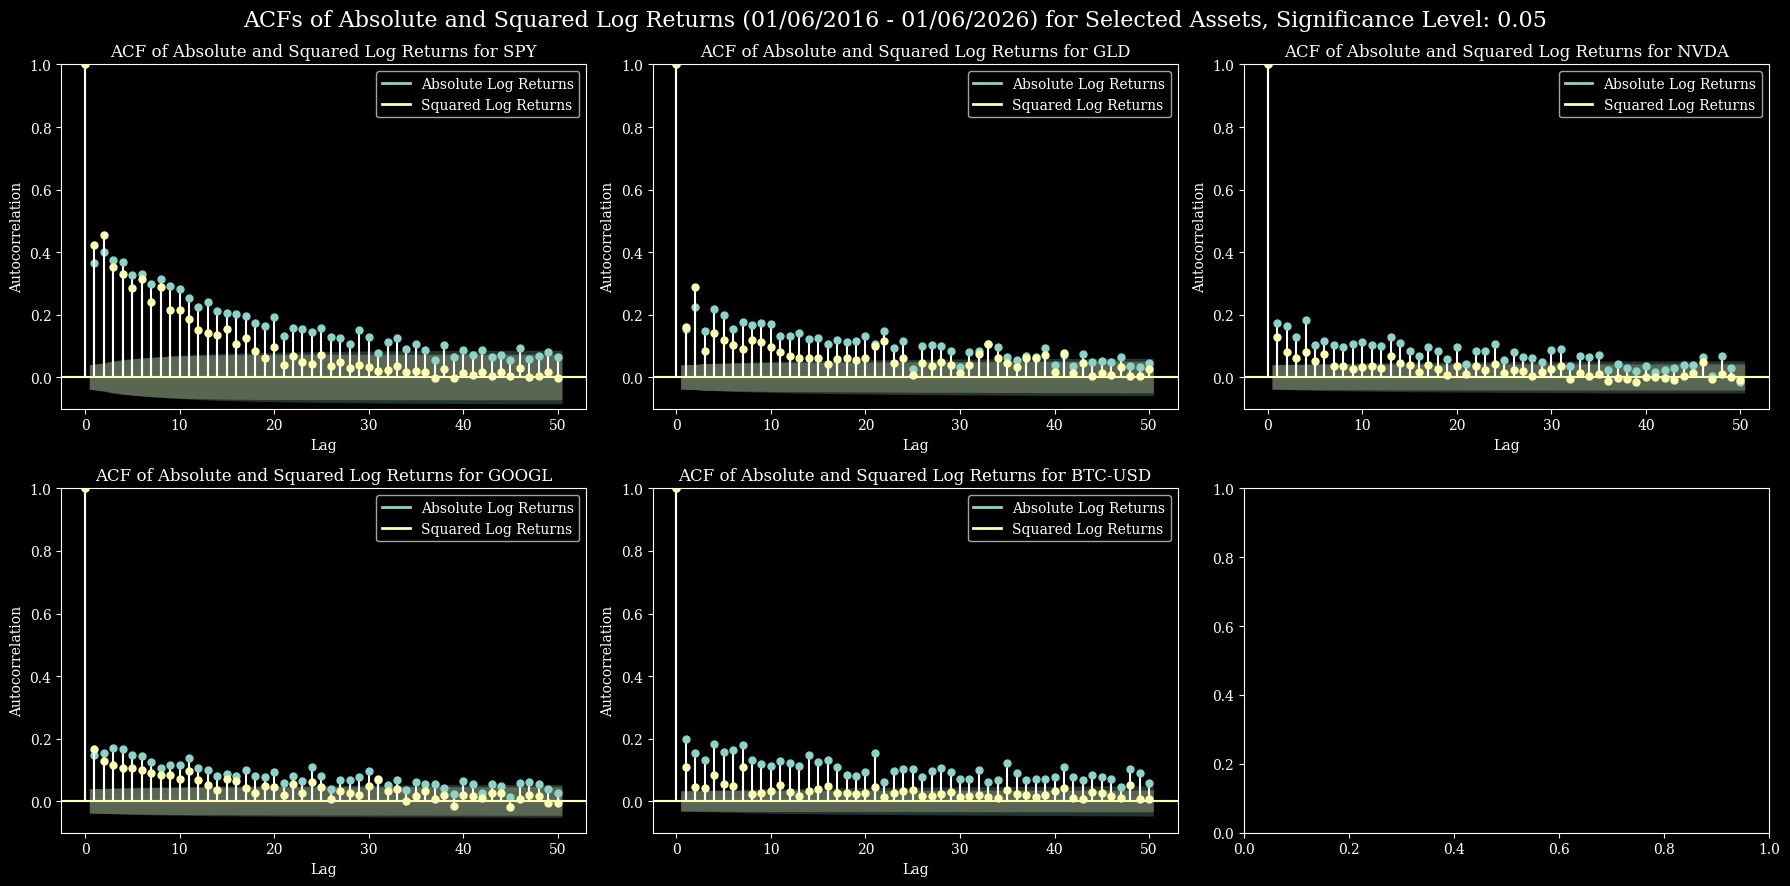

In [ ]:
fig, axs = plt.subplots(
    len(tickers) // 3 + (1 if len(tickers) % 3 else 0),
    3,
    figsize=(18, 9), squeeze=False
)

fig.suptitle(
    f"ACFs of Absolute and Squared Log Returns (01/06/2016 - 01/06/2026) for Selected Assets, Significance Level: {significance_level}",
    fontsize=16
)

lags = 50

for i, ticker in enumerate(tickers):
    ax = axs[i // 3, i % 3]

    # sm.graphics.tsa.plot_acf(
    #     np.abs(log_returns[ticker]),
    #     lags=lags,
    #     alpha=significance_level,
    #     ax=ax,
    #     color='C0'
    # )

    # sm.graphics.tsa.plot_acf(
    #     log_returns_squared[ticker],
    #     lags=lags,
    #     alpha=significance_level,
    #     ax=ax,
    #     color='C1'
    # )

    # legend_handles = [
    #     Line2D([0], [0], color='C0', lw=2, label='Absolute Log Returns'),
    #     Line2D([0], [0], color='C1', lw=2, label='Squared Log Returns')
    # ]

    # ax.legend(handles=legend_handles)
    # ax.set_title(f'ACF of Absolute and Squared Log Returns for {ticker}')
    # ax.set_xlabel('Lag')
    # ax.set_ylabel('Autocorrelation')
    # ax.set_ylim(-0.1, 1)  # Set y-axis limits for better visualization

    # manual version, no CI bands though
    acf_abs = sm.tsa.stattools.acf(np.abs(log_returns[ticker]), nlags=lags)
    acf_sq = sm.tsa.stattools.acf(log_returns_squared[ticker], nlags=lags)

    ax.plot(range(len(acf_abs)), acf_abs, marker='o', label='Absolute Log Returns')
    ax.plot(range(len(acf_sq)), acf_sq, marker='o', label='Squared Log Returns')

    ax.set_title(f'ACF of Absolute and Squared Log Returns for {ticker}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.legend()

plt.tight_layout()
plt.show()

# Why Geometric Brownian Motion (GBM) Breaks
"A stochastic process S_t is said to follow a GBM if it satisfies the following SDE: 
$$dS_t = μS_tdt + σS_tdW_t \quad (1)$$
where $W_t$ is a Wiener process or Brownian motion, and $μ$ ('the percentage drift') and $σ$ ('the percentage volatility') are constants."

The solution is to the above SDE is $$S_t = S_0\exp((μ - \frac{σ^2}{2})t + σW_t)\quad (2)$$

If we factor $S_t$ in (1), we can more intuitively understand what the SDE and thus GBM means. We get:
$$\frac{dS_t}{S_t} = μdt + σdW_t \quad (3)$$
This gives us our intuitive idea of GBM: the relative change of a stochastic process following GBM is due to a constant deterministic component $μdt$, and a stochastic (random) movement $σdW_t$.

There are two main assumptions that in practice break with GBM. Firstly, $σ$, i.e. volatility, is assumed to be constant. In real stock prices, volatility changes over time, possibly even stochastically. Secondly, the process is assumed to be continuous (it is a continuous stochastic process), but in real life stock prices can have "jumps" caused by unpredictable news or events, which translate to discontinutities in mathematical terms.

$W_t$, called the Wiener process, is normally distributed with mean 0 and variance t (i.e. the increments of a Wiener process are i.i.d N(0, t) variables). Thus, $dW_t$ ~ N(0, 1), so we would expect the returns ($\frac{dS_t}{S_t}$) to be normally distributed as well. As the results show, this is not the case. This at least in part is caused by the broken GBM assumptions mentioned previously, but could also be due to other less rigorous factors, like human psychology.